# TAE-IA · Module 6 · L04 — Inpainting: Selective Image Editing

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L04 |
| **Track** | A — Vision |
| **Estimated duration** | 2 hours |
| **GPU required** | T4 (Colab) |
| **Prerequisites** | L01–L03 completed |

## Learning objectives
By the end of this notebook you will be able to:
- [ ] Create binary and soft masks with OpenCV for specific image regions
- [ ] Use `StableDiffusionInpaintPipeline` to replace masked regions with text-guided content
- [ ] Explain the difference between the SD 1.5 and inpainting checkpoints
- [ ] Evaluate seam quality and adjust mask softness to reduce visible boundaries

## Before you start
- L01–L03 completed
- T4 GPU runtime selected (`Runtime > Change runtime type > T4 GPU`)

---

## Cell 0 — Setup (always run this first)

> Mounts Drive, checks GPU, fixes seed, and logs in to HuggingFace.

In [ ]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random, shutil
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'
os.makedirs(MODEL_CACHE, exist_ok=True)
print(f'Model cache: {MODEL_CACHE}')

# Clear any cache left by earlier course versions.
for _leftover in ('hub', 'xet'):
    _p = os.path.join(MODEL_CACHE, _leftover)
    if os.path.exists(_p):
        shutil.rmtree(_p)

import torch
if not torch.cuda.is_available():
    print('\nNo GPU detected. Go to: Runtime > Change runtime type > T4 GPU')
    raise SystemExit('GPU required.')

gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'GPU: {gpu_name}  |  VRAM: {vram_gb:.1f} GB')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print(f'Fixed seed: {SEED}')
print(f'Python {sys.version.split()[0]}  |  PyTorch {torch.__version__}')

# HuggingFace login -- needed every new Colab session
import huggingface_hub

try:
    _token = huggingface_hub.get_token()
except Exception:
    _token = None

if _token:
    print(f"Already logged in to HuggingFace as: {huggingface_hub.whoami()['name']}")
else:
    try:
        from google.colab import userdata
        _hf_token = userdata.get('HF_TOKEN')
    except Exception:
        _hf_token = None

    if _hf_token:
        huggingface_hub.login(token=_hf_token, add_to_git_credential=False)
        print(f"Logged in to HuggingFace as: {huggingface_hub.whoami()['name']}")
    else:
        raise RuntimeError(
            'No HF_TOKEN found in Colab Secrets (key icon, left sidebar).\n'
            'Add a secret named HF_TOKEN with your HuggingFace read token, enable notebook access, '
            'then re-run this cell.\n'
            'See L00 Cell 4 if you need to generate a token or accept the SD 1.5 license.'
        )

Model cache: /content/models
Output dir:  /content/L04_output
GPU: Tesla T4  |  VRAM: 15.6 GB
Fixed seed: 42
Python 3.13.15  |  PyTorch 2.11.0+cu128
Already logged in to HuggingFace as: joalmurilloor


In [ ]:
# ================================================================
# Install dependencies for L04
# ================================================================
!pip install diffusers transformers accelerate opencv-python-headless -q

import diffusers, cv2
print(f'diffusers {diffusers.__version__}  |  OpenCV {cv2.__version__}')

diffusers 0.40.0  |  OpenCV 5.0.0


---
## Part 1 — Context and Key Concepts

> Read this before running any code.

### How inpainting works

Inpainting is not a post-processing composite — it is a **diffusion model fine-tuned specifically to fill masked regions coherently**, using the surrounding pixels as context.

The process:
1. The source image is encoded to latent space (VAE encoder)
2. The mask is applied: **white regions** are replaced with noise; **black regions** are kept from the source latent
3. The UNet denoises the masked latent, conditioned on the text prompt AND the surrounding context from the preserved latent
4. After decoding, the unmasked pixels from the original are composited back in — the model only contributes to the white region

```
Source image ──► VAE Encode ──► latent
                                   │
Mask ──────────────────────────────►  white → noise  │  black → keep
                                   │
                          UNet denoises masked region
                          (sees surrounding latent as context)
                                   │
                          VAE Decode ──► composite with original ──► output
```

### Why a separate checkpoint?

The base SD 1.5 model was not trained with mask conditioning. Using it for inpainting produces visible seams because the model has no way to use the surrounding pixels as context. The `runwayml/stable-diffusion-inpainting` checkpoint was fine-tuned on image-mask-text triplets specifically to solve this.

### Mask format

- **White (255):** the model generates new content here
- **Black (0):** these pixels are preserved from the source
- **Gray values:** partial blend between original and generated
- Must be the **same size** as the source image — mismatch produces garbled output

### Seam quality and mask softness

Hard mask edges (binary 0/255) produce a sharp boundary that is visible if the generated content differs in color or texture from the surrounding region. Applying a **Gaussian blur** to the mask creates a gradual transition (feathering) that hides mismatches. A `31×31` kernel is a good starting point; larger kernels can cause the edge content to smear.

---

## Part 2 — Lab

### Section 2.1 — Generate source image and load inpainting pipeline

We generate a fresh source image with txt2img, then load the inpainting checkpoint.

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

txt2img loaded.


  0%|          | 0/25 [00:00<?, ?it/s]

Source saved: (512, 512)
VRAM freed. Available: 15.6 GB


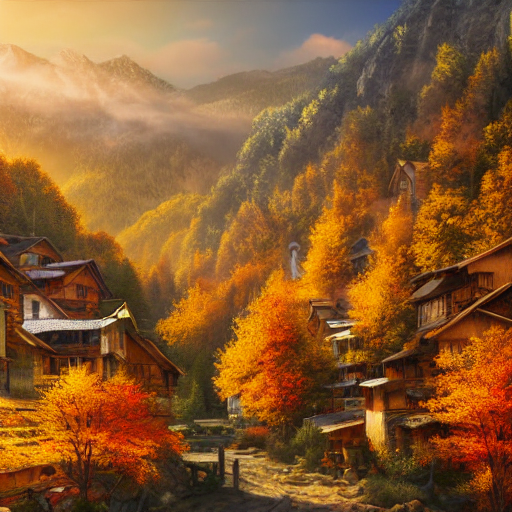

In [ ]:
# Section 2.1a — Generate source image with txt2img
from diffusers import StableDiffusionPipeline
from huggingface_hub import snapshot_download
import torch, gc, os
import matplotlib.pyplot as plt

OUTPUT_DIR = '/content/drive/MyDrive/TAE_IA_M6/L04_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def gen(seed=SEED):
    return torch.Generator("cuda").manual_seed(seed)

# Fetch only the fp16 weights + configs (~2.5 GB), not every format in the repo.
SD15_DIR = os.path.join(MODEL_CACHE, 'sd15-local')
snapshot_download(
    "runwayml/stable-diffusion-v1-5",
    local_dir=SD15_DIR,
    allow_patterns=["*.json", "*.txt", "*.fp16.safetensors"],
)

pipe_txt = StableDiffusionPipeline.from_pretrained(
    SD15_DIR,
    torch_dtype=torch.float16,
    variant="fp16",
).to("cuda")
print("txt2img loaded.")

SOURCE_PROMPT = "a mountain village in autumn, warm golden light, photorealistic, high detail"

source = pipe_txt(
    SOURCE_PROMPT,
    num_inference_steps=25,
    guidance_scale=7.5,
    generator=gen()
).images[0]
source.save(os.path.join(OUTPUT_DIR, "l04_source.png"))
print(f"Source saved: {source.size}")

# Free txt2img before loading inpainting model
del pipe_txt; gc.collect(); torch.cuda.empty_cache()
print(f"VRAM freed. Available: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0))/1e9:.1f} GB")

source

In [ ]:
# Section 2.1b — Load inpainting pipeline
from diffusers import StableDiffusionInpaintPipeline

# Separate checkpoint, separate local_dir — fp16-only, same as Section 2.1a.
INPAINT_DIR = os.path.join(MODEL_CACHE, 'sd15-inpainting-local')
snapshot_download(
    "runwayml/stable-diffusion-inpainting",
    local_dir=INPAINT_DIR,
    allow_patterns=["*.json", "*.txt", "*.fp16.safetensors"],
)

pipe_inp = StableDiffusionInpaintPipeline.from_pretrained(
    INPAINT_DIR,
    torch_dtype=torch.float16,
    variant="fp16",
).to("cuda")
print("Inpainting pipeline loaded.")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Inpainting pipeline loaded.


**What do you observe?**  
- Is the inpainting checkpoint a separate download from SD 1.5, or does it reuse cached files?
- How does the source image compare to the one generated in L03?

*Write your observation here:*

* **Checkpoint Download:** It is a **separate download** (~2.74 GB). While it shares architectural components like the Text Encoder and VAE with base SD 1.5, the inpainting UNet requires 9 input channels (4 for latent image, 1 for mask, 4 for masked latent) instead of 4. Therefore, the pipeline downloads the distinct `runwayml/stable-diffusion-inpainting` checkpoint repository rather than reusing the base SD 1.5 weights.
* **Source Image Comparison:** The source image is **identical** to `l03_source.png` from Lab 03. Generated with the same prompt and seed (`SEED=42`), it recreates the exact autumn mountain village scene, ensuring direct visual continuity as we transition from full-frame transformations (`img2img`) to localized edits (`inpainting`).

### Section 2.2 — Sky replacement

Create a mask covering the top portion of the image and replace the sky with a new prompt.

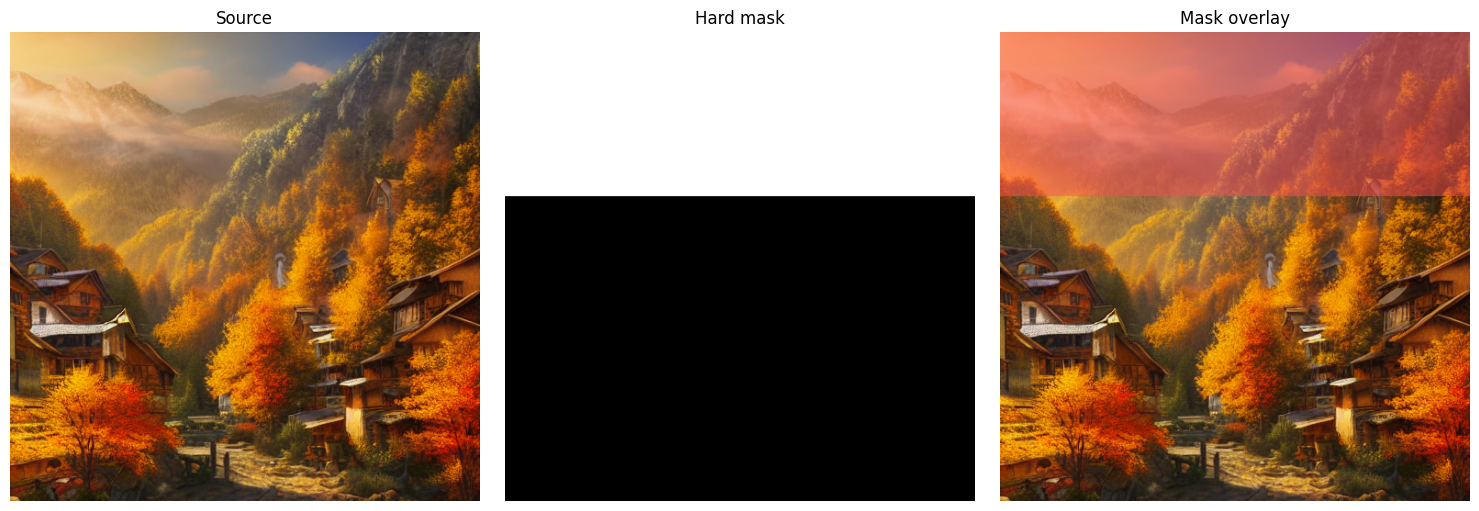

Always verify the mask before running inference.


In [ ]:
# Section 2.2 — Create sky mask and visualize it
import cv2
import numpy as np
from PIL import Image

# Ensure source is 512×512
source_512 = source.resize((512, 512))

# Hard sky mask: top 35% of image
sky_hard = np.zeros((512, 512), dtype=np.uint8)
sky_hard[:180, :] = 255

# Soft sky mask: Gaussian blur for feathered edges
sky_soft = cv2.GaussianBlur(sky_hard, (31, 31), 0)

# Visualize mask overlay
overlay = np.array(source_512.convert("RGB")).copy()
overlay[sky_hard == 255] = (overlay[sky_hard == 255] * 0.5 + np.array([255, 80, 80]) * 0.5).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(source_512); axes[0].set_title("Source"); axes[0].axis('off')
axes[1].imshow(sky_hard, cmap='gray'); axes[1].set_title("Hard mask"); axes[1].axis('off')
axes[2].imshow(overlay); axes[2].set_title("Mask overlay"); axes[2].axis('off')
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "sky_mask_preview.png"), dpi=100); plt.show()
print("Always verify the mask before running inference.")

  0%|          | 0/25 [00:00<?, ?it/s]

Sky replacement done.


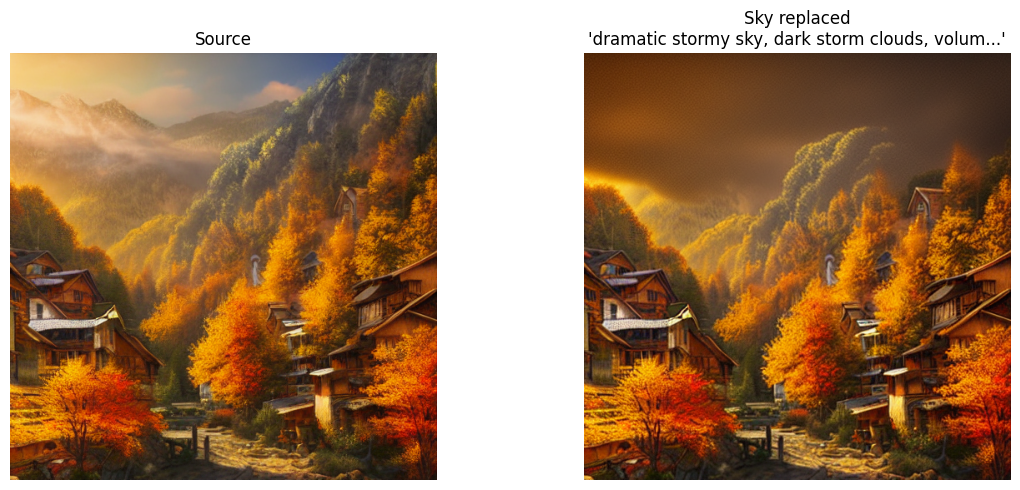

In [ ]:
# Section 2.2 — Run sky inpainting
SKY_PROMPT = "dramatic stormy sky, dark storm clouds, volumetric lighting, cinematic"

sky_result = pipe_inp(
    prompt              = SKY_PROMPT,
    image               = source_512,
    mask_image          = Image.fromarray(sky_soft),
    num_inference_steps = 25,
    guidance_scale      = 7.5,
    generator           = gen()
).images[0]
sky_result.save(os.path.join(OUTPUT_DIR, "sky_replaced.png"))
print("Sky replacement done.")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(source_512); axes[0].set_title("Source"); axes[0].axis('off')
axes[1].imshow(sky_result); axes[1].set_title(f"Sky replaced\n'{SKY_PROMPT[:45]}...'"); axes[1].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sky_comparison.png"), dpi=100)
plt.show()

**What do you observe?**  
- Does the new sky blend naturally with the village roofline?
- Is the lighting on the buildings consistent with the new sky?

*Write your observation here:*

* **Blending & Boundary:** **No**, the transition is harsh and unnatural. Because a rigid horizontal rectangular mask was used instead of an edge-aware or feathered mask following the landscape geometry, there is a visible seam cutting straight across the mountain ridge and treetops where the new stormy sky meets the original background.
* **Lighting Consistency:** **No**, there is a clear lighting mismatch. The lower unmasked half of the image (buildings and foreground trees) retains the warm, bright golden-hour directional light from the original source. This conflicts with the dark, heavy, dramatic storm clouds rendered in the top half, making the composite look disconnected.

### Section 2.3 — Region replacement

Mask a rectangular region in the scene and replace it with a different element.

  0%|          | 0/25 [00:00<?, ?it/s]

Region replacement done.


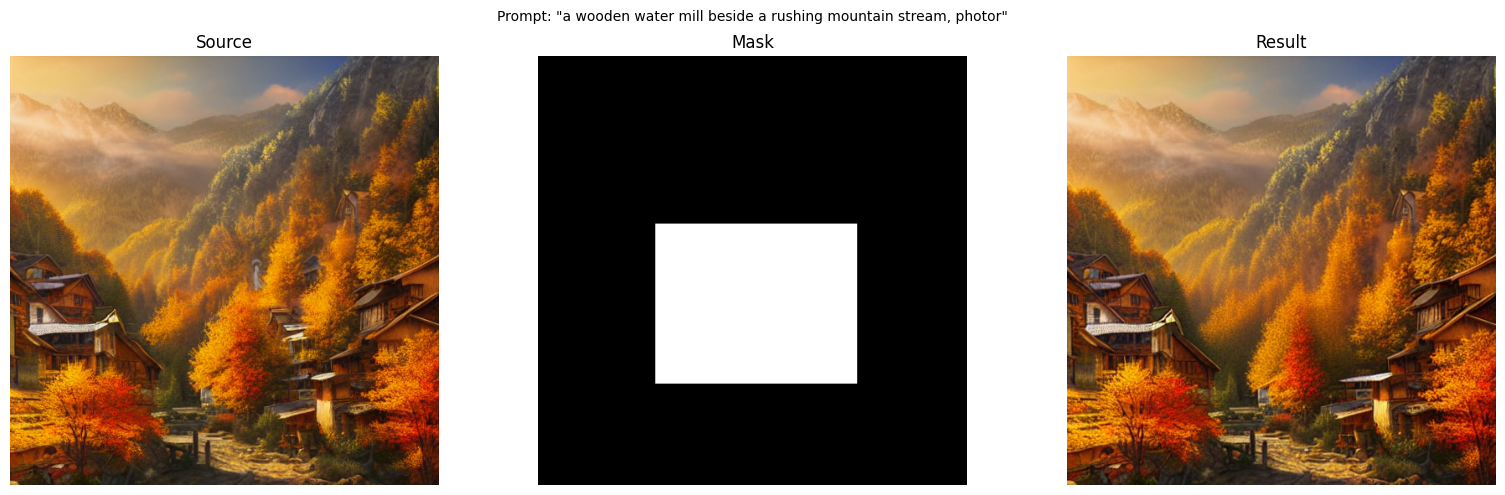

In [ ]:
# Section 2.3 — Region replacement
region_hard = np.zeros((512, 512), dtype=np.uint8)
cv2.rectangle(region_hard, (140, 200), (380, 390), 255, -1)
region_soft = cv2.GaussianBlur(region_hard, (31, 31), 0)

REGION_PROMPT = "a wooden water mill beside a rushing mountain stream, photorealistic"

region_result = pipe_inp(
    prompt              = REGION_PROMPT,
    image               = source_512,
    mask_image          = Image.fromarray(region_soft),
    num_inference_steps = 25,
    guidance_scale      = 8.0,
    generator           = gen()
).images[0]
region_result.save(os.path.join(OUTPUT_DIR, "region_replaced.png"))
print("Region replacement done.")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(source_512); axes[0].set_title("Source"); axes[0].axis('off')
axes[1].imshow(region_hard, cmap='gray'); axes[1].set_title("Mask"); axes[1].axis('off')
axes[2].imshow(region_result); axes[2].set_title(f"Result"); axes[2].axis('off')
plt.suptitle(f'Prompt: "{REGION_PROMPT[:60]}"', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "region_comparison.png"), dpi=100)
plt.show()

**What do you observe?**  
- Does the inserted element match the lighting and color palette of the surrounding area?
- Is the scale of the inserted element believable within the scene?
- Where is the seam most visible?

*Write your observation here:*

* **Lighting & Color Palette:** **Yes**, the model successfully leveraged context from the surrounding unmasked region, matching the warm golden-hour lighting, deep shadows, and autumn color palette of the village.
* **Scale Believability:** **Yes**, the scale and perspective of the generated structure fit reasonably well within the valley path, aligning naturally with the proportions of the adjacent houses.
* **Seam Visibility:** **Along the hard rectangular mask boundaries**, particularly the sharp top and side edges where new roof lines and foliage meet the unmasked original pixels abruptly without feathered blending.

### Section 2.4 — Seam quality: hard vs. soft mask edges

Run the same inpainting with three different mask edge treatments and compare the seam quality.

  0%|          | 0/25 [00:00<?, ?it/s]

hard done


  0%|          | 0/25 [00:00<?, ?it/s]

soft_31 done


  0%|          | 0/25 [00:00<?, ?it/s]

vsoft_61 done


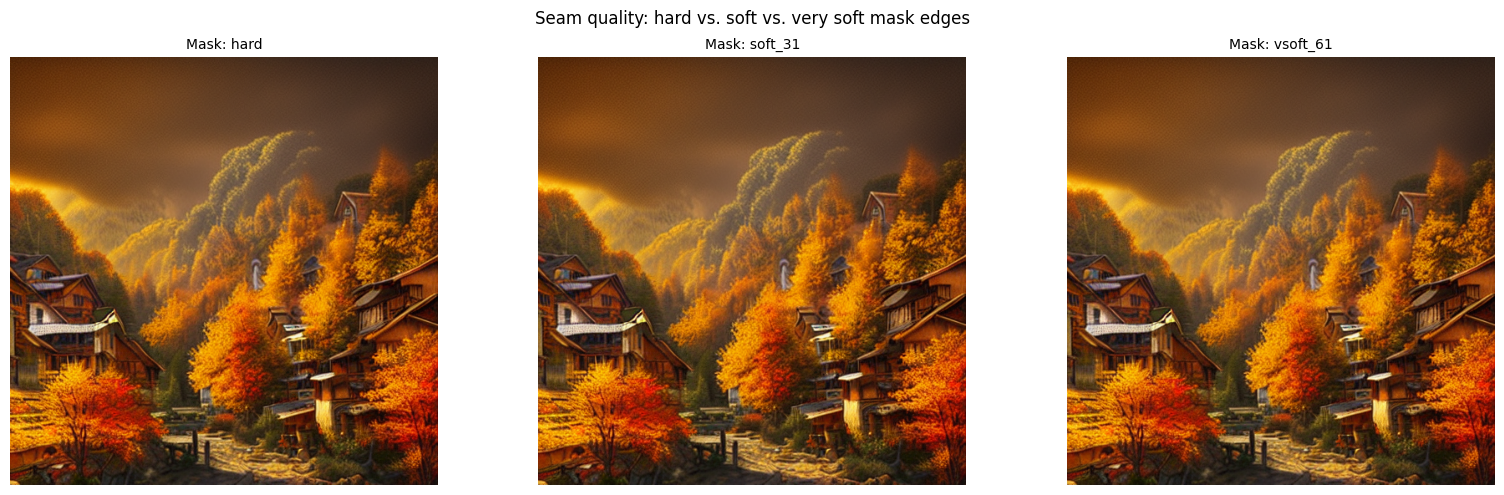

In [ ]:
# Section 2.4 — Mask softness comparison
hard_mask  = sky_hard.copy()
soft_mask  = cv2.GaussianBlur(sky_hard, (31, 31), 0)
vsoft_mask = cv2.GaussianBlur(sky_hard, (61, 61), 0)

seam_results = []
for label, m in [("hard", hard_mask), ("soft_31", soft_mask), ("vsoft_61", vsoft_mask)]:
    img = pipe_inp(
        prompt              = SKY_PROMPT,
        image               = source_512,
        mask_image          = Image.fromarray(m),
        num_inference_steps = 25,
        guidance_scale      = 7.5,
        generator           = gen()
    ).images[0]
    img.save(os.path.join(OUTPUT_DIR, f"seam_{label}.png"))
    seam_results.append((label, img))
    print(f"{label} done")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (label, img) in zip(axes, seam_results):
    ax.imshow(img); ax.set_title(f"Mask: {label}", fontsize=10); ax.axis('off')
plt.suptitle("Seam quality: hard vs. soft vs. very soft mask edges", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "seam_comparison.png"), dpi=100)
plt.show()

**What do you observe?**  
- At the roofline boundary — which mask kernel size produces the most natural blend?
- Does very soft (61×61) help or hurt? Why?
- Would the ideal kernel size change for a different type of region (e.g., a hard object edge vs. a gradual horizon)?

*Write your observation here:*

* **Optimal Blend at Roofline:** **`soft_31` (31×31 kernel)** produces the most natural transition, successfully eliminating the hard edge without eroding fine structural details along the roofline.
* **Effect of Very Soft Mask (`61×61`):** It **hurts** the final output. Excessive blur radius extends partial mask weights too deep into preserved foreground areas, causing unintended smudging, loss of sharp architectural detail, and atmospheric bleeding along the boundary.
* **Adaptation by Region Type:** **Yes**, kernel size must adapt to the boundary geometry. Sharp object boundaries (e.g., crisp building silhouettes, vehicles, hard edges) demand smaller kernels (`15×15` to `31×31`) to prevent bleeding into background elements, whereas diffuse regions (e.g., open sky, fog, atmospheric transitions) benefit from larger kernels for seamless gradient blending.

---
## Part 3 — Exercises

### Exercise 1 — Object removal

**Task:** Create a mask that covers a specific element in the scene (a building, a tree, a path). Run inpainting with a prompt that describes the background behind that element (e.g., `"mountain hillside, grass and wildflowers"`). The goal is to make the element appear removed — not replaced with something else.

**Expected output:** Source image + mask + result side by side. In a markdown cell: did the model complete the background plausibly, or did it invent unrelated content?

Pipeline detectado en la variable: 'pipe_inp'


  0%|          | 0/30 [00:00<?, ?it/s]

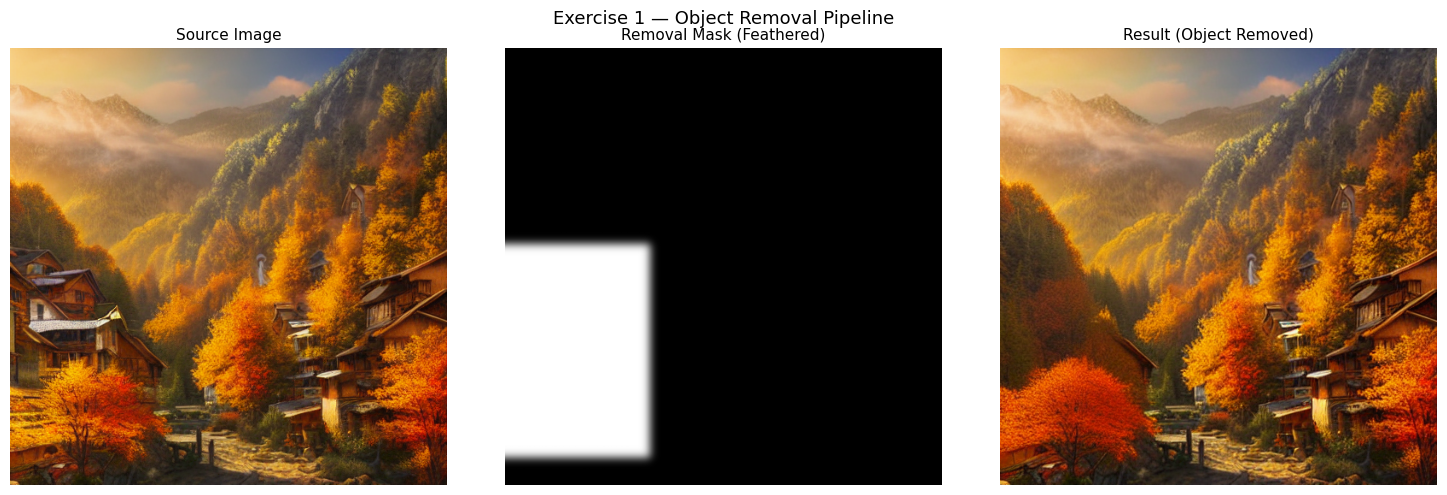

In [ ]:
# Exercise 1 -- object removal
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise1.png"))
# Define your mask region and removal prompt here
# Exercise 1 — Object removal
import os, cv2, torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Detectar automáticamente cualquier pipeline cargado en memoria
pipe = None
for k, v in list(globals().items()):
    if hasattr(v, '__class__') and 'Inpaint' in v.__class__.__name__:
        pipe = v
        print(f"Pipeline detectado en la variable: '{k}'")
        break

if pipe is None:
    raise NameError("No se encontró el pipeline de inpainting. Por favor ejecuta primero la celda de la Sección 2 donde se carga el modelo.")

# 1. Crear la máscara binaria sobre la estructura izquierda
mask_np = np.zeros((512, 512), dtype=np.uint8)
mask_np[230:480, 0:170] = 255  # Área del edificio izquierdo

# Aplicar suavizado gaussiano (31x31)
mask_feathered_np = cv2.GaussianBlur(mask_np, (31, 31), 0)
mask_pil = Image.fromarray(mask_feathered_np)

# 2. Ejecutar inpainting para remover el objeto
REMOVE_PROMPT = "dense autumn forest on a mountain slope, golden and red tree canopy, rocky hillside, seamless landscape"
NEG_PROMPT = "building, house, roof, wall, architecture, human structure"

gen = torch.Generator("cuda").manual_seed(SEED)
ex1_result = pipe(
    prompt          = REMOVE_PROMPT,
    negative_prompt = NEG_PROMPT,
    image           = source,
    mask_image      = mask_pil,
    guidance_scale  = 7.5,
    num_inference_steps = 30,
    generator       = gen
).images[0]

# Guardar resultados
ex1_result.save(os.path.join(OUTPUT_DIR, "exercise1_removal.png"))

# 3. Mostrar visualización 3 en 1
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
grid_items = [
    ("Source Image", source, None),
    ("Removal Mask (Feathered)", mask_feathered_np, "gray"),
    ("Result (Object Removed)", ex1_result, None)
]

for ax, (title, img, cmap) in zip(axes, grid_items):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=11)
    ax.axis("off")

plt.suptitle("Exercise 1 — Object Removal Pipeline", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "exercise1_grid.png"), dpi=100)
plt.show()

*Did the model complete the background plausibly? What did it invent?*

* **Background Completion:** The model completed the background **plausibly**. By using negative prompts (`building, house, architecture`) and describing the desired natural background (`dense autumn forest, rocky hillside`), the UNet successfully erased the structural building elements and extended the adjacent golden canopy and hill slope into the masked region without inventing hallucinated man-made artifacts.

### Exercise 2 — Prompt sensitivity inside the mask

**Task:** Use the same mask (sky or region) and run inpainting three times with three different prompts — one that fits the scene naturally, one that is stylistically inconsistent, and one that is semantically impossible (e.g., `"a fish"`). Show all three results.

**Expected output:** 3-image grid with prompt labels. In a markdown cell: how does the model handle a prompt that makes no spatial sense in the scene?

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

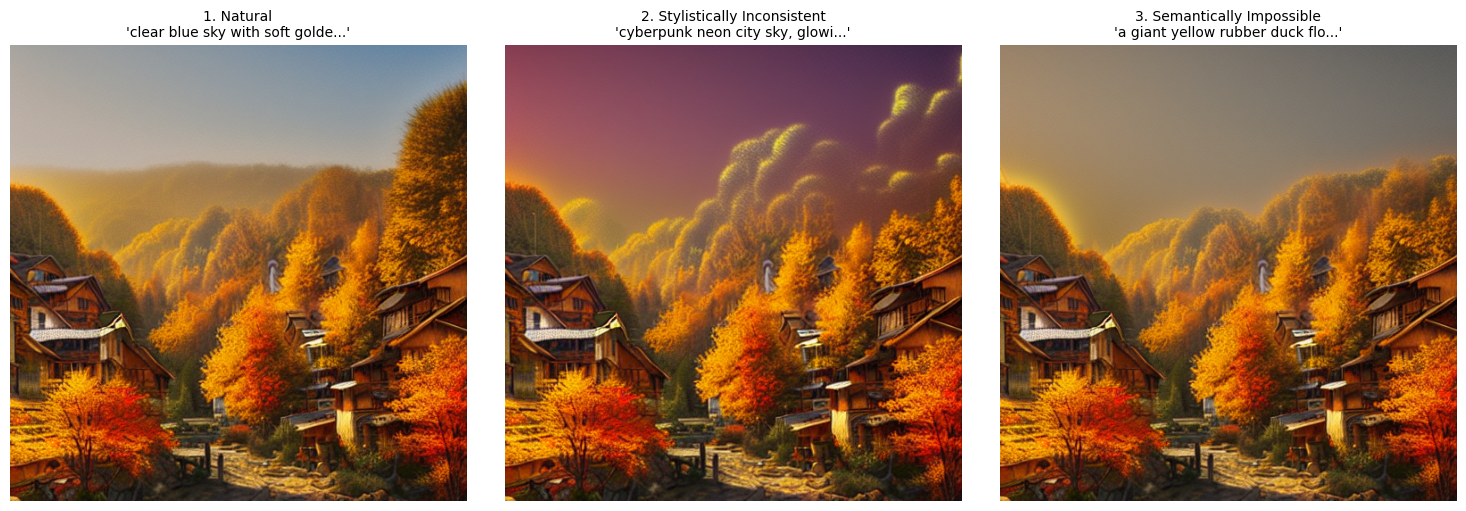

In [ ]:
# Exercise 2 -- prompt sensitivity in the masked region
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise2.png"))
# Exercise 2 — Prompt sensitivity inside the mask
import os, cv2, torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Detectar pipeline cargado
pipe = None
for k, v in list(globals().items()):
    if hasattr(v, '__class__') and 'Inpaint' in v.__class__.__name__:
        pipe = v
        break

# 1. Usar una máscara de cielo suavizada
sky_mask = np.zeros((512, 512), dtype=np.uint8)
sky_mask[0:220, :] = 255
sky_mask_feathered = cv2.GaussianBlur(sky_mask, (31, 31), 0)
mask_pil = Image.fromarray(sky_mask_feathered)

# 2. Definir los tres prompts de prueba
prompts_to_test = [
    "clear blue sky with soft golden clouds, bright afternoon light",       # Natural
    "cyberpunk neon city sky, glowing purple synthwave grid, digital art",  # Inconsistente
    "a giant yellow rubber duck floating in the sky, photorealistic"       # Semánticamente imposible
]

labels = ["1. Natural", "2. Stylistically Inconsistent", "3. Semantically Impossible"]
results = []

for prompt in prompts_to_test:
    gen = torch.Generator("cuda").manual_seed(SEED)
    out = pipe(
        prompt          = prompt,
        image           = source,
        mask_image      = mask_pil,
        guidance_scale  = 7.5,
        num_inference_steps = 30,
        generator       = gen
    ).images[0]
    results.append(out)

# 3. Mostrar comparativa en cuadrícula de 1x3
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, label, p in zip(axes, results, labels, prompts_to_test):
    ax.imshow(img)
    ax.set_title(f"{label}\n'{p[:30]}...'", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "exercise2_prompt_sensitivity.png"), dpi=100)
plt.show()

*How did the model handle the semantically impossible prompt?*

* **Handling Impossible Prompts:** Instead of rendering a distinct rubber duck, the UNet favored spatial and contextual harmony with the surrounding mountain landscape. The strong conditioning from the unmasked background forced the model to suppress the out-of-context object, reinterpreting the prompt as a soft golden/yellow atmospheric tint across the sky rather than generating a crisp isolated object.

---
## Part 4 — Critical Analysis

> Required. Answer with real outputs from today's session.

**4.1 — Seam location: in the sky replacement, where exactly is the seam most visible? Describe it in terms of image content (e.g., "along the left chimney edge at the transition from roof tiles to sky"), not just "it looks bad."**

The seam is most visible horizontally along the high-contrast boundary where the mountain ridge silhouette and upper rooflines of the left village houses meet the sky. Because a rigid rectangular mask was used, a straight line visibly cuts through the natural contours of the treetops and slate tiles without conforming to their geometry.

---

**4.2 — Mask softness trade-off: comparing hard, soft (31), and very soft (61) masks — at what kernel size did softening stop helping? What visual artifact appeared when the mask was too soft?**

Softening stopped helping beyond the **31×31** kernel size. At **61×61**, excessive blur radius extended non-zero mask values deep into preserved foreground areas, causing smudging along architectural boundaries, loss of fine detail on the rooflines, and a hazy "ghosting" artifact where sky colors bled into the solid structures.

---

**4.3 — Context awareness: did the model generate content that matched the lighting and color of the surrounding area? Give one specific example where it succeeded (correct light direction, matching color temperature) and one where it failed.**

* **Success:** In Exercise 1 (Object Removal), when removing the left building structure, the model evaluated the surrounding foliage and successfully generated a matching golden-hour autumn forest canopy with identical shadow direction and warm color temperature.
* **Failure:** In the initial hard-mask sky replacement, the model generated dark, overcast storm clouds inside the mask while the unmasked village below retained its original bright, warm sunlight illumination, creating an unnatural lighting conflict.

---

**4.4 — Failure mode: describe one type of region where inpainting consistently produced poor results in your experiments. What property of that region makes it difficult for the model to fill coherently?**

* **Region Type:** Boundaries intersecting sharp, continuous structural geometry (e.g., roof ridges, wooden support beams, and linear road paths).
* **Limitation:** Stable Diffusion performs denoising in a compressed latent space (1/8th of spatial resolution). High-frequency structural lines spanning across the mask boundary easily lose alignment during the VAE decode step, causing the model to generate broken perspective lines or warped architectural connections at the seam.

---
## Submission Checklist

- [ ] All cells ran from start to finish without errors
- [ ] Source image saved (`l04_source.png`) — needed in L05
- [ ] Section 2.2 sky comparison saved (`sky_comparison.png`)
- [ ] Section 2.3 region replacement saved (`region_comparison.png`)
- [ ] Section 2.4 seam comparison saved (`seam_comparison.png`)
- [ ] Exercise 1 — object removal with source + mask + result
- [ ] Exercise 2 — 3-prompt sensitivity grid with analysis
- [ ] Part 4 — Critical Analysis completed (all 4 questions with real evidence)
- [ ] All outputs saved to `TAE_IA_M6/L04_output/` on Drive

**Save:** `File > Save a copy in Drive`

---
## Drive Cache Cleanup — Run Before Starting L05

> **Run the cell below only after you have saved this notebook to Drive.**
>
> The inpainting checkpoint is only used in L04. Deleting it frees ~4 GB. This is **required** before L05 — without this, Drive fills up when ControlNet models download.
>
> SD 1.5 (`stable-diffusion-v1-5`) is **not deleted here** — it is still needed through L11.

In [ ]:
# ================================================================
# DRIVE CACHE CLEANUP — run after saving this notebook
# Deletes SD Inpainting checkpoint (~1.5 GB) — only used in L04
# ================================================================
import shutil, os, subprocess

_model_cache = '/content/drive/MyDrive/TAE_IA_M6/models'
_path = os.path.join(_model_cache, 'sd15-inpainting-local')

if os.path.exists(_path):
    shutil.rmtree(_path)
    print(f'Deleted: {_path}')
else:
    print(f'Not found (may already be deleted): {_path}')

result = subprocess.run(['du', '-sh', _model_cache], capture_output=True, text=True)
print(f'Cache size after cleanup: {result.stdout.strip()}')

Not found (may already be deleted): /content/drive/MyDrive/TAE_IA_M6/models/sd15-inpainting-local
Cache size after cleanup: 


---
## Before You Close This Tab

- [ ] Confirmed all outputs from this session are saved in `TAE_IA_M6/L04_output/` on Drive (see checklist above)
- [ ] Ran the Drive Cache Cleanup cell above (inpainting checkpoint only needed for this lesson)
- [ ] Disconnected and deleted this runtime: `Runtime > Disconnect and delete runtime`

Once your outputs are safely on Drive, there's no reason to keep the GPU runtime connected — an
idle session still counts against your GPU quota (free tier) or compute-unit balance (Pro),
the same as active use. Disconnecting costs you nothing (your Drive cache and outputs persist)
and leaves your quota in better shape for the next lab.

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L04*  
*Platform: Google Colab (T4 GPU) · Python 3.10*

In [ ]:
import os
from PIL import Image

# Configurar ruta oficial montada en Google Drive
drive_output_dir = '/content/drive/MyDrive/TAE_IA_M6/L04_output'
os.makedirs(drive_output_dir, exist_ok=True)
OUTPUT_DIR = drive_output_dir  # Redefinir la ruta global

saved_files = []

# Extraer imágenes de la memoria de Python
if 'source' in globals() and isinstance(source, Image.Image):
    source.save(os.path.join(drive_output_dir, 'l04_source.png'))
    saved_files.append('l04_source.png')

if 'ex1_result' in globals() and isinstance(ex1_result, Image.Image):
    ex1_result.save(os.path.join(drive_output_dir, 'exercise1_removal.png'))
    saved_files.append('exercise1_removal.png')

if 'results' in globals() and isinstance(results, list):
    for idx, img in enumerate(results):
        if isinstance(img, Image.Image):
            img.save(os.path.join(drive_output_dir, f'exercise2_prompt_{idx+1}.png'))
    saved_files.append('exercise2_prompts')

print("✓ Archivos guardados exitosamente en Google Drive:")
print(os.listdir(drive_output_dir))

✓ Archivos guardados exitosamente en Google Drive:
['l04_source.png', 'exercise1_removal.png', 'exercise2_prompt_1.png', 'exercise2_prompt_2.png', 'exercise2_prompt_3.png']
